In [1]:
import torch
import time
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from datasets import load_dataset
from matplotlib import pyplot as plt
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import accuracy_score

C:\Users\musae\Desktop\files\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


# Загрузка данных

In [4]:
ds = load_dataset('uoft-cs/cifar10')
ds

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

In [5]:
ds["train"].features

{'img': Image(mode=None, decode=True),
 'label': ClassLabel(names=['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'])}

In [6]:
sample = ds["train"][0]
print(type(sample))
print(sample)

<class 'dict'>
{'img': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=32x32 at 0x2667FC62110>, 'label': 0}


In [7]:
class CifarDataset(Dataset):
    def __init__(self, data, transforms):
        self.data = data
        self.transforms = transforms
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        item = self.data[idx]

        image = item['img']
        label = item['label']

        if self.transforms:
            image = self.transforms(image)
        return image, label

In [8]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

In [9]:
cifar10_train = CifarDataset(ds['train'], transforms=transform_train)

g = torch.Generator()
g.manual_seed(seed)

cifar10_loader_train = DataLoader(
    cifar10_train,
    batch_size=32,
    shuffle=True,
    generator=g
)

In [10]:
cifar10_test = CifarDataset(ds['test'], transforms=transform_test)

cifar10_loader_test = DataLoader(
    cifar10_test, 
    batch_size=128, 
    shuffle=False
)

# Создание модели

In [11]:
class GaussianActivationNoise(nn.Module):
    def __init__(self, sigma, relative):
        super().__init__()
        self.sigma = sigma
        self.relative = relative
    def forward(self, x):
        if not self.training or self.sigma == 0:
            return x
        
        noise = torch.randn_like(x)

        if self.relative:
            scale = x.detach().std()
            return x + self.sigma * scale * noise
        else:
            return x + self.sigma * noise

In [12]:
class Net(nn.Module):
    def __init__(self, sigma1=0, sigma2=0, sigma3=0, relative=True):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            GaussianActivationNoise(sigma1, relative),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            GaussianActivationNoise(sigma1, relative),
            nn.MaxPool2d(2)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            GaussianActivationNoise(sigma2, relative),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            GaussianActivationNoise(sigma2, relative),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(8*8*64, 256),
            nn.ReLU(),
            GaussianActivationNoise(sigma3, relative),
            nn.Dropout(0.5),
            nn.Linear(256, 10),
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)

        return x

# Обучение

In [13]:
num_epochs = 20
lr = 1e-2

In [14]:
criterion = nn.CrossEntropyLoss()

In [15]:
def evaluate(model, val_loader, final=False):
    model.eval()

    correct = 0
    running_loss = 0.0
    
    correct_pred = {i: 0 for i in range(10)}
    total_pred = {i: 0 for i in range(10)}

    with torch.no_grad():
        for data, target in val_loader:
            data = data.to(device)
            target = target.to(device)

            output = model(data)
            loss = criterion(output, target)

            running_loss += loss.item()

            pred = output.argmax(dim=1)

            correct += pred.eq(target.data).sum()

            for label, prediction in zip(target, pred):
                label = label.item()
                prediction = prediction.item()
                if label == prediction:
                    correct_pred[label] += 1
    
                total_pred[label] += 1
                

    accuracy = correct / len(val_loader.dataset)
    avg_loss = running_loss / len(val_loader)

    if final:
        for i in range(10):
            acc = 100 * correct_pred[i] / total_pred[i]
            print(f"Accuracy class {i} = {acc:.1f} %")
        

    return accuracy.cpu().item(), avg_loss

In [16]:
def train(net, num_epochs):
    losses = []
    for epoch in range(num_epochs):
        net.train()
        running_loss = 0.0
        for batch_idx, (data, target) in enumerate(cifar10_loader_train):
            data = data.to(device)
            target = target.to(device)
            
            optimizer.zero_grad()
    
            net_out = net(data)
            loss = criterion(net_out, target)
            loss.backward()
            optimizer.step()
    
            running_loss += loss.item()
        if epoch == num_epochs-1: 
            val_acc, val_loss = evaluate(net, cifar10_loader_test, True)
        else:
            val_acc, val_loss = evaluate(net, cifar10_loader_test)
        losses.append(running_loss/len(cifar10_loader_train))
        print(f'epoch: {epoch+1}, train loss: {running_loss/len(cifar10_loader_train)}, val_acc: {val_acc}, val_loss: {val_loss}')

        plt.plot(losses)
        plt.xlabel("Эпоха")
        plt.ylabel("Loss");

epoch: 1, train loss: 1.8961461496444674, val_acc: 0.44519999623298645, val_loss: 1.584685456903675
epoch: 2, train loss: 1.447743807743546, val_acc: 0.611799955368042, val_loss: 1.065258138541934
epoch: 3, train loss: 1.1494234062812303, val_acc: 0.7049999833106995, val_loss: 0.8489362605010407
epoch: 4, train loss: 1.0047171835478346, val_acc: 0.7137999534606934, val_loss: 0.7959407537798339
epoch: 5, train loss: 0.9181222998973886, val_acc: 0.733199954032898, val_loss: 0.764129646971256
epoch: 6, train loss: 0.8525362926954195, val_acc: 0.7622999548912048, val_loss: 0.6887566937675959
epoch: 7, train loss: 0.8088589171263475, val_acc: 0.7738999724388123, val_loss: 0.6397811974151225
epoch: 8, train loss: 0.7674679479973483, val_acc: 0.7787999510765076, val_loss: 0.6469743515871749
epoch: 9, train loss: 0.7424911990695021, val_acc: 0.7774999737739563, val_loss: 0.6395946160147462
epoch: 10, train loss: 0.7108009982989983, val_acc: 0.805899977684021, val_loss: 0.5663130969940862
epoch

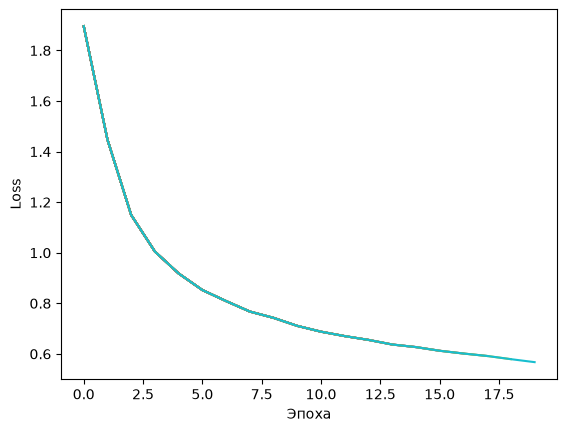

In [17]:
start = time.time()

net = Net(0, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.872449240620443, val_acc: 0.4968999922275543, val_loss: 1.357484191278868
epoch: 2, train loss: 1.4302287961684659, val_acc: 0.6060000061988831, val_loss: 1.0951308049733126
epoch: 3, train loss: 1.171605421081233, val_acc: 0.6697999835014343, val_loss: 0.9233829341357267
epoch: 4, train loss: 1.0236801956795152, val_acc: 0.7023999691009521, val_loss: 0.8774707400346105
epoch: 5, train loss: 0.9442369974124759, val_acc: 0.7340999841690063, val_loss: 0.7465866283525394
epoch: 6, train loss: 0.8783312498836737, val_acc: 0.7351999878883362, val_loss: 0.761355641521985
epoch: 7, train loss: 0.8239076196079596, val_acc: 0.7662000060081482, val_loss: 0.6771971688994879
epoch: 8, train loss: 0.7840783687752939, val_acc: 0.7698000073432922, val_loss: 0.6665565020675901
epoch: 9, train loss: 0.7557327970433373, val_acc: 0.7476999759674072, val_loss: 0.746927606908581
epoch: 10, train loss: 0.7296115360863302, val_acc: 0.785099983215332, val_loss: 0.6349391548693935
epoch

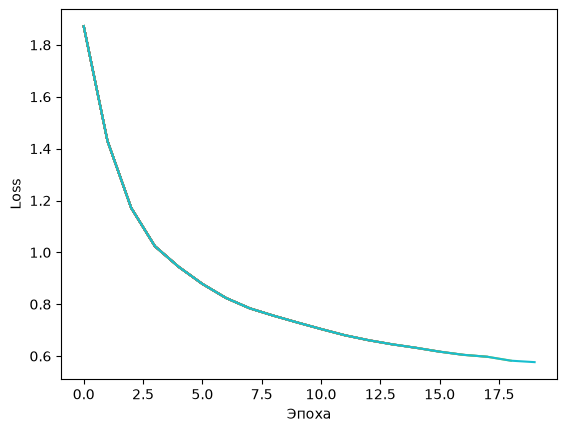

In [18]:
start = time.time()

net = Net(0.03, 0, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.8506316096067277, val_acc: 0.4732999801635742, val_loss: 1.4335776446740838
epoch: 2, train loss: 1.444236411662416, val_acc: 0.5922999978065491, val_loss: 1.1191986640797387
epoch: 3, train loss: 1.1844431479161777, val_acc: 0.6579999923706055, val_loss: 0.9372926150696187
epoch: 4, train loss: 1.0394731045379444, val_acc: 0.6967999935150146, val_loss: 0.9081877809536608
epoch: 5, train loss: 0.9416592184427985, val_acc: 0.7488999962806702, val_loss: 0.7212745969808554
epoch: 6, train loss: 0.8891835656405563, val_acc: 0.7531999945640564, val_loss: 0.7169711955740482
epoch: 7, train loss: 0.8235360039439784, val_acc: 0.7753999829292297, val_loss: 0.6708760072913351
epoch: 8, train loss: 0.7874392850785704, val_acc: 0.7664999961853027, val_loss: 0.7038814998880217
epoch: 9, train loss: 0.7511749791549859, val_acc: 0.7924000024795532, val_loss: 0.6101605616792848
epoch: 10, train loss: 0.7246937656242421, val_acc: 0.7953000068664551, val_loss: 0.6072073246859298


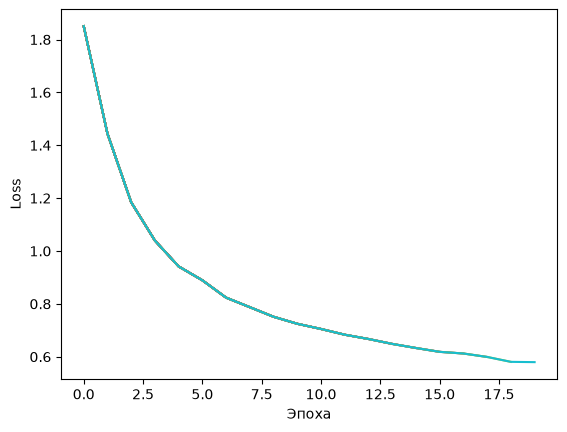

In [19]:
start = time.time()

net = Net(0, 0.03, 0)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.87186217048728, val_acc: 0.4796999990940094, val_loss: 1.3664275905753993
epoch: 2, train loss: 1.429051917139262, val_acc: 0.608299970626831, val_loss: 1.0659948051730288
epoch: 3, train loss: 1.1590805372898958, val_acc: 0.6687999963760376, val_loss: 0.9245942084095146
epoch: 4, train loss: 1.014533646752723, val_acc: 0.7057999968528748, val_loss: 0.8559788850289357
epoch: 5, train loss: 0.9341628377779279, val_acc: 0.7454999685287476, val_loss: 0.7246079957937892
epoch: 6, train loss: 0.8655103564986951, val_acc: 0.7414000034332275, val_loss: 0.7422596917876715
epoch: 7, train loss: 0.8203232984129466, val_acc: 0.7524999976158142, val_loss: 0.7275159370295609
epoch: 8, train loss: 0.7884448310235183, val_acc: 0.7518999576568604, val_loss: 0.7208016937292074
epoch: 9, train loss: 0.7589071667964689, val_acc: 0.7811999917030334, val_loss: 0.6356510316269307
epoch: 10, train loss: 0.7273111004270351, val_acc: 0.7820999622344971, val_loss: 0.6284017713764046
epoc

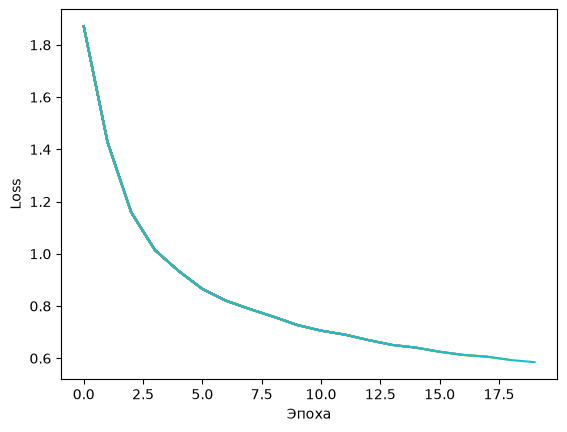

In [20]:
start = time.time()

net = Net(0, 0, 0.03)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.8999480666522406, val_acc: 0.43529999256134033, val_loss: 1.4986842734904229
epoch: 2, train loss: 1.4840214282217044, val_acc: 0.583899974822998, val_loss: 1.161808785758441
epoch: 3, train loss: 1.2134362322660264, val_acc: 0.6858999729156494, val_loss: 0.8913425441029705
epoch: 4, train loss: 1.0519309987529148, val_acc: 0.7014999985694885, val_loss: 0.8337037948113454
epoch: 5, train loss: 0.956703529000206, val_acc: 0.7300999760627747, val_loss: 0.7683656830576402
epoch: 6, train loss: 0.8945912271452041, val_acc: 0.7312999963760376, val_loss: 0.79514630874501
epoch: 7, train loss: 0.8386795619551524, val_acc: 0.7681999802589417, val_loss: 0.684929068329968
epoch: 8, train loss: 0.7962416902956716, val_acc: 0.7658999562263489, val_loss: 0.6824909063834178
epoch: 9, train loss: 0.7626092150492769, val_acc: 0.7863999605178833, val_loss: 0.6218336599914334
epoch: 10, train loss: 0.7356827023104834, val_acc: 0.7947999835014343, val_loss: 0.6071464936190014
epoc

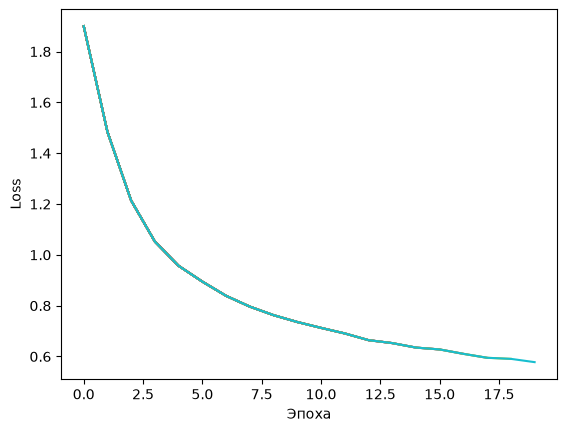

In [21]:
start = time.time()

net = Net(0.03, 0.03, 0.03)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.8613523885521917, val_acc: 0.4583999812602997, val_loss: 1.4352379418626617
epoch: 2, train loss: 1.4556647674135879, val_acc: 0.6126999855041504, val_loss: 1.1225815430472168
epoch: 3, train loss: 1.2027696271546742, val_acc: 0.6686999797821045, val_loss: 0.9497926552084428
epoch: 4, train loss: 1.0545960203699782, val_acc: 0.698199987411499, val_loss: 0.866734193095678
epoch: 5, train loss: 0.9583449943547667, val_acc: 0.7240999937057495, val_loss: 0.8078081886979598
epoch: 6, train loss: 0.8922825984404168, val_acc: 0.7497000098228455, val_loss: 0.7203510049023206
epoch: 7, train loss: 0.8359013416411705, val_acc: 0.7436999678611755, val_loss: 0.7269618081141122
epoch: 8, train loss: 0.8067933159879744, val_acc: 0.7502999901771545, val_loss: 0.7543881097926369
epoch: 9, train loss: 0.7687287514055683, val_acc: 0.7773000001907349, val_loss: 0.6559389727779582
epoch: 10, train loss: 0.741261271105618, val_acc: 0.7960000038146973, val_loss: 0.6096250196046467
ep

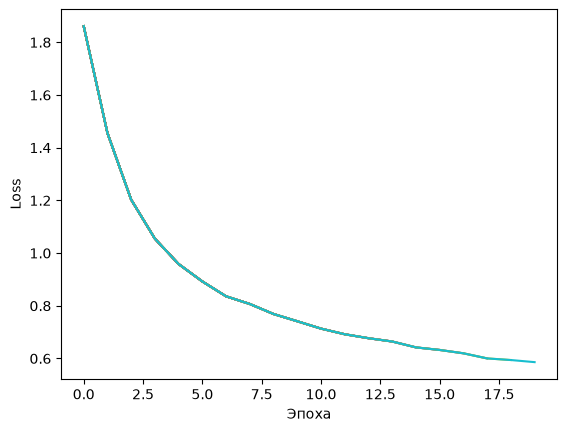

In [22]:
start = time.time()

net = Net(0.05, 0.03, 0.01)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.877836557359018, val_acc: 0.5005999803543091, val_loss: 1.3885426853276506
epoch: 2, train loss: 1.445089880770319, val_acc: 0.5421000123023987, val_loss: 1.274694540832616
epoch: 3, train loss: 1.1803867545024143, val_acc: 0.6556000113487244, val_loss: 0.9730894731569893
epoch: 4, train loss: 1.0325428605537268, val_acc: 0.7055999636650085, val_loss: 0.8336349559735649
epoch: 5, train loss: 0.9399074594408597, val_acc: 0.7342000007629395, val_loss: 0.7723152199877968
epoch: 6, train loss: 0.8715461452878291, val_acc: 0.7440999746322632, val_loss: 0.7438476345961607
epoch: 7, train loss: 0.8314373560121101, val_acc: 0.7723000049591064, val_loss: 0.6814651255366169
epoch: 8, train loss: 0.7914873958015319, val_acc: 0.7770000100135803, val_loss: 0.6728210867960241
epoch: 9, train loss: 0.757937712159892, val_acc: 0.7845999598503113, val_loss: 0.6269338179992724
epoch: 10, train loss: 0.7299311433418851, val_acc: 0.7899999618530273, val_loss: 0.6075898042962521
epo

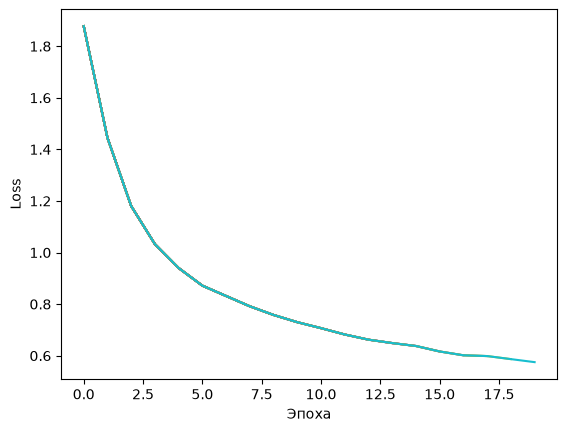

In [23]:
start = time.time()

net = Net(0.01, 0.03, 0.05)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.8532702628420623, val_acc: 0.45499998331069946, val_loss: 1.4966600378857384
epoch: 2, train loss: 1.4200886200806, val_acc: 0.5537999868392944, val_loss: 1.254457102546209
epoch: 3, train loss: 1.1691338293688158, val_acc: 0.6489999890327454, val_loss: 0.9482918924923185
epoch: 4, train loss: 1.02546151444764, val_acc: 0.7095999717712402, val_loss: 0.815635202051718
epoch: 5, train loss: 0.9409827892588105, val_acc: 0.7328000068664551, val_loss: 0.7912088157255438
epoch: 6, train loss: 0.8797129350294307, val_acc: 0.7461999654769897, val_loss: 0.7209176617332652
epoch: 7, train loss: 0.8286214215932408, val_acc: 0.7595999836921692, val_loss: 0.6901717306692389
epoch: 8, train loss: 0.7992426844758249, val_acc: 0.7676999568939209, val_loss: 0.6793506100207944
epoch: 9, train loss: 0.7611514076123387, val_acc: 0.784500002861023, val_loss: 0.6306171507775029
epoch: 10, train loss: 0.7346714224978586, val_acc: 0.7387999892234802, val_loss: 0.7908423535431488
epoch:

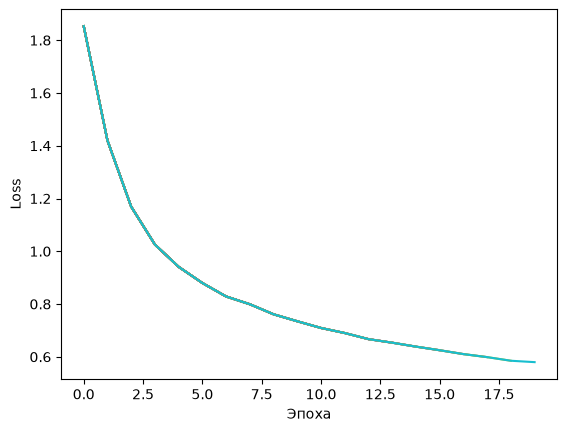

In [24]:
start = time.time()

net = Net(0, 0, 0.01)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20)

print('Время обучения', time.time() - start)

epoch: 1, train loss: 1.8355075934721885, val_acc: 0.48899999260902405, val_loss: 1.3748284729221198
epoch: 2, train loss: 1.4246324024288912, val_acc: 0.6216999888420105, val_loss: 1.0729718404480173
epoch: 3, train loss: 1.1907848986920377, val_acc: 0.675000011920929, val_loss: 0.9168737085559701
epoch: 4, train loss: 1.0322004300771581, val_acc: 0.6261000037193298, val_loss: 1.1332630386835412
epoch: 5, train loss: 0.933784770588042, val_acc: 0.7483999729156494, val_loss: 0.7192310970040816
epoch: 6, train loss: 0.869561629080269, val_acc: 0.7473999857902527, val_loss: 0.7629219957544834
epoch: 7, train loss: 0.8242011938198819, val_acc: 0.7583000063896179, val_loss: 0.7123693759682812
epoch: 8, train loss: 0.7864601487962389, val_acc: 0.7849999666213989, val_loss: 0.6291670901111409
epoch: 9, train loss: 0.7595430754044082, val_acc: 0.7817999720573425, val_loss: 0.6669390797615051
epoch: 10, train loss: 0.7245660458363101, val_acc: 0.7967999577522278, val_loss: 0.5952396868150446
e

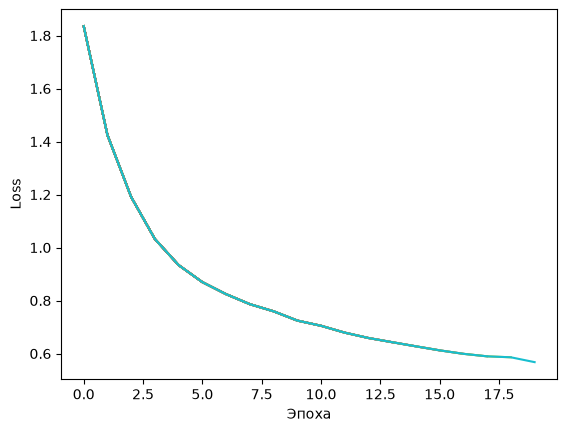

In [25]:
start = time.time()

net = Net(0, 0, 0.05)
net.to(device)
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
train(net, 20)

print('Время обучения', time.time() - start)